In [1]:
PRODUCTION_QUALITY = False

import ipdb
import json
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
import seaborn as sns
import pandas as pd
import os
import re
import warnings

from itertools import cycle
from labellines import labelLines

plt.style.use(['science', 'bright'])

dpi = 300 if PRODUCTION_QUALITY else 100

plt.rcParams.update({
    'text.usetex': True,
    'font.size': 12,
    'font.family': 'lmodern',
    'savefig.bbox': 'tight',
    'savefig.format': 'pdf',
    'figure.constrained_layout.use': True,
    'legend.frameon': True,
    'savefig.dpi': dpi,
})

EXPERIMENT_BASE='18-hpo-alternatives'

# Beamer 16:9
WIDTH=455.24408

#WIDTH=441.01775
OUTPUT_DIR=f'../{EXPERIMENT_BASE}/images'

os.makedirs(OUTPUT_DIR, exist_ok=True) # make sure it exists

# image saving format
IMG_FORMAT = 'png'

# Mapping of full model names to abbreviations
MODEL_NAME_MAP = {
    'vit_base_patch16_224.augreg_in21k': 'ViT',
    'resnetv2_50x1_bit.goog_in21k': 'ResNetV2',
}

N_BOOTSTRAP_SAMPLES=100

In [2]:
def set_size(width_pt, fraction=1, subplots=(1, 1), y_scale=False):
    """Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    ----------
    width: float or string
            Document width in points, or string of predined document type
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    # https://disq.us/p/2940ij3
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt

    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])
    
    if y_scale:
        fig_height_in = fig_height_in * y_scale

    return (fig_width_in, fig_height_in)

In [3]:
def get_figure(subplots, fraction=1.0, y_scale=False):
    figsize = set_size(WIDTH, fraction=fraction, subplots=subplots, y_scale=y_scale)
    fig, axes = plt.subplots(subplots[0], subplots[1], figsize=figsize, constrained_layout=True)

    return fig, axes

In [4]:
def read_json_data(file_path):
    with open(file_path, 'r') as file:
        return json.load(file)

In [5]:
def prepare_data(data):
    records = []
    for experiment_details in data:
        experiment_name = experiment_details['configuration']['experiment_name']
        dataset_name = experiment_details['configuration']['dataset_name']
        subset_size = experiment_details['configuration']['subset_size']
        pretrained = experiment_details['configuration']['pretrained']
        epochs = experiment_details['hyperparameters']['epochs']
        epsilon = experiment_details['hyperparameters']['target_epsilon']
        seed = experiment_details['configuration']['seed']

        # Get HPO method from experiment name
        if 'fixed_params' in experiment_name:
            hpo_method = 'fixed_params'
        elif 'seeded_warmup' in experiment_name:
            hpo_method = 'seeded_warmup'
        elif 'full_optimization' in experiment_name:
            hpo_method = 'full_optimization'
        else:
            hpo_method = 'unknown'

        # Get parameters according to the HPO method
        best_params = experiment_details.get('best_params', {})
        hyperparams = experiment_details.get('hyperparameters', {})
        target_hypers = experiment_details['configuration'].get('target_hypers', [])

        # Fetch the optimized or fixed learning rate, batch size, and max grad norm
        learning_rate = best_params.get('learning_rate') if 'learning_rate' in target_hypers else hyperparams.get('learning_rate')
        batch_size = best_params.get('batch_size') if 'batch_size' in target_hypers else hyperparams.get('batch_size')
        max_grad_norm = best_params.get('max_grad_norm') if 'max_grad_norm' in target_hypers else hyperparams.get('max_grad_norm')

        # Handle the full batch size case
        if batch_size == -1:
            full_batch_size = 7500 if 'humans' in dataset_name else 5000
            batch_size = full_batch_size

        record = {
            'experiment_name': experiment_name,
            'runtime': experiment_details['runtime'],
            'model_name': experiment_details['configuration']['model_name'],
            'dataset_name': dataset_name,
            'subset_size': subset_size,
            'epsilon': epsilon,
            'max_grad_norm': max_grad_norm,
            'accuracy': float(experiment_details['best_value']),
            'learning_rate': learning_rate,
            'batch_size': batch_size,
            'epochs': epochs,
            'pretrained': pretrained,
            'seed': seed,
            'hpo_method': hpo_method,
        }

        # Add final metrics if available
        for metric_name, metric_value in experiment_details.get('final_metrics', {}).items():
            record[metric_name] = metric_value

        records.append(record)

    df = pd.DataFrame(records)
    return df


# Accuracy trends by noise level

In [6]:
def plot_method_comparison_by_dataset(data, output_dir=None):
    method_order = ['fixed_params', 'seeded_warmup', 'full_optimization']
    method_palette = {'fixed_params': 'blue', 'seeded_warmup': 'green', 'full_optimization': 'orange'}

    datasets = data['dataset_name'].unique()

    for dataset in datasets:
        dataset_data = data[data['dataset_name'] == dataset]
        fig, ax = get_figure((1, 1))
        # Plot accuracy with confidence intervals across all seeds
        sns.pointplot(
            x='hpo_method',
            y='MulticlassAccuracy',
            data=dataset_data,
            errorbar=('ci', 95),
            order=method_order,
            hue='hpo_method',  # Colors by method
            palette=method_palette,
            markers='o',
            ax=ax,
            legend=False,
        )

        # Set plot title and labels
        dataset_name = dataset.split("/")[-1]
        ax.set_title(f'Accuracy Comparison by HPO Method for {dataset_name}')
        ax.set_xlabel('HPO Method')
        ax.set_ylabel('Accuracy')
        ax.grid(True, axis='y', linestyle='--', alpha=0.7)

        # Legend
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', label='Fixed Params', markerfacecolor=method_palette['fixed_params'], markersize=8),
            Line2D([0], [0], marker='o', color='w', label='Seeded Warmup', markerfacecolor=method_palette['seeded_warmup'], markersize=8),
            Line2D([0], [0], marker='o', color='w', label='Full Optimization', markerfacecolor=method_palette['full_optimization'], markersize=8)
        ]
        ax.legend(handles=legend_elements, title="HPO Method", loc='upper left', bbox_to_anchor=(1, 1))

        # Save plot if output_dir is provided
        if output_dir:
            plt.savefig(f"{output_dir}/method_comparison_{dataset_name}_all_seeds.png", bbox_inches='tight')

        plt.show()

In [7]:
def plot():
    file_path = f'../{EXPERIMENT_BASE}/processed-data/aggregated_data.json'
    data = read_json_data(file_path)
    processed_data = prepare_data(data)
    plot_method_comparison_by_dataset(processed_data, output_dir=OUTPUT_DIR)

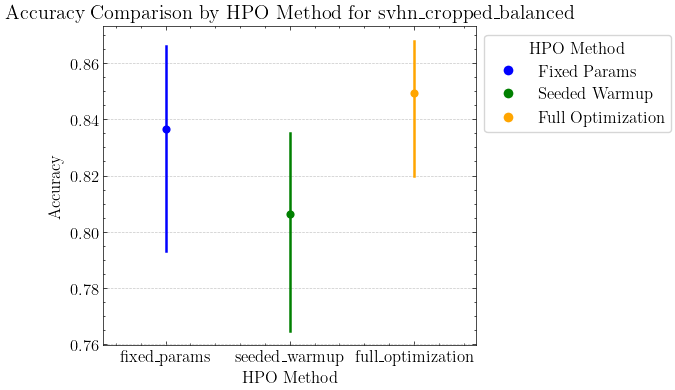

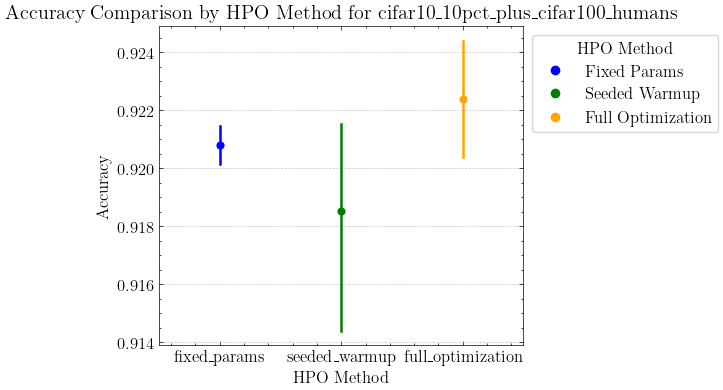

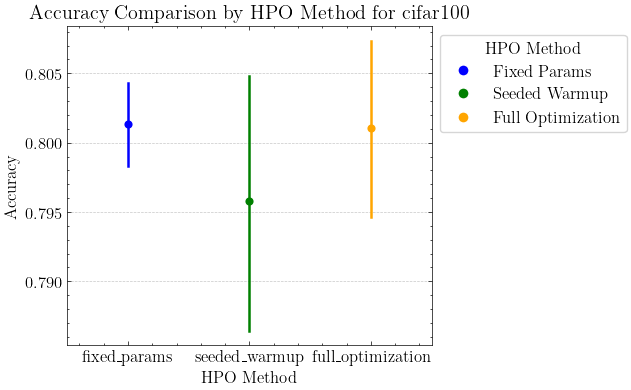

In [8]:
plot()

In [9]:
def create_latex_accuracy_table(data, std_multiplier=1.5):
    # Group data by dataset and HPO method, sort values within each group
    grouped = data.groupby(['dataset_name', 'hpo_method'])
    
    # Calculate mean and std for each group to identify outliers
    stats = grouped['MulticlassAccuracy'].agg(['mean', 'std']).reset_index()
    stats.set_index(['dataset_name', 'hpo_method'], inplace=True)
    
    # Determine the maximum number of accuracy values for consistent row count
    max_values = max(group['MulticlassAccuracy'].size for _, group in grouped)

    # Start building the LaTeX table
    latex_table = r"""
\begin{table}[ht]
\centering
\caption{Sorted Multiclass Accuracy Values for Each Dataset and HPO Method. Headers abbreviations: \textbf{C10} = CIFAR-10 10\% + CIFAR-100 Humans, \textbf{C100} = CIFAR-100 10\%, \textbf{SVHN} = SVHN Cropped Balanced 10\%; \textbf{FP} = Fixed Params, \textbf{SW} = Seeded Warmup, \textbf{FO} = Full Optimization. Outliers (values > 1.5 std deviations from the mean) are in \textbf{bold}.}
\label{table:transposed_accuracy}
\begin{tabular}{""" + " | ".join(["c"] * len(grouped)) + r"""}
\hline
"""

    # Create header row using the custom abbreviations
    headers = []
    for (dataset, method), _ in grouped:
        if 'cifar10_10pct_plus_cifar100_humans' in dataset:
            dataset_abbrev = 'C10'
        elif 'cifar100' in dataset:
            dataset_abbrev = 'C100'
        elif 'svhn_cropped_balanced' in dataset:
            dataset_abbrev = 'SVHN'
        else:
            dataset_abbrev = 'XX'  # Fallback in case of unrecognized dataset

        # Map method to abbreviation
        if method == 'fixed_params':
            method_abbrev = 'FP'
        elif method == 'seeded_warmup':
            method_abbrev = 'SW'
        elif method == 'full_optimization':
            method_abbrev = 'FO'
        else:
            method_abbrev = 'XX'  # Fallback for unrecognized method

        # Combine dataset and method abbreviations
        headers.append(f"{dataset_abbrev}-{method_abbrev}")
        
    latex_table += " & ".join(headers) + r" \\" + "\n\\hline\n"

    # Populate the rows with sorted accuracy values, using 3 decimal places and bold for outliers
    for i in range(max_values):
        row_values = []
        for (dataset, method), group in grouped:
            sorted_accuracies = group['MulticlassAccuracy'].sort_values().values
            if i < len(sorted_accuracies):
                value = sorted_accuracies[i]
                
                # Check if this value is an outlier
                mean = stats.loc[(dataset, method), 'mean']
                std_dev = stats.loc[(dataset, method), 'std']
                lower_bound = mean - std_multiplier * std_dev
                upper_bound = mean + std_multiplier * std_dev
                if value < lower_bound or value > upper_bound:
                    row_values.append(f"\\textbf{{{value:.3f}}}")  # Bold outliers
                else:
                    row_values.append(f"{value:.3f}")
            else:
                row_values.append("")  # Fill empty cells if fewer values in this group

        # Join row values without trailing "&"
        latex_table += " & ".join(row_values) + r" \\" + "\n"
    
    # Close the table
    latex_table += r"""
\hline
\end{tabular}
\end{table}
"""

    print(latex_table)


In [10]:
file_path = f'../{EXPERIMENT_BASE}/processed-data/aggregated_data.json'
data = read_json_data(file_path)
processed_data = prepare_data(data)

create_latex_accuracy_table(processed_data)


\begin{table}[ht]
\centering
\caption{Sorted Multiclass Accuracy Values for Each Dataset and HPO Method. Headers abbreviations: \textbf{C10} = CIFAR-10 10\% + CIFAR-100 Humans, \textbf{C100} = CIFAR-100 10\%, \textbf{SVHN} = SVHN Cropped Balanced 10\%; \textbf{FP} = Fixed Params, \textbf{SW} = Seeded Warmup, \textbf{FO} = Full Optimization. Outliers (values > 1.5 std deviations from the mean) are in \textbf{bold}.}
\label{table:transposed_accuracy}
\begin{tabular}{c | c | c | c | c | c | c | c | c}
\hline
C100-FP & C100-FO & C100-SW & C10-FP & C10-FO & C10-SW & SVHN-FP & SVHN-FO & SVHN-SW \\
\hline
\textbf{0.793} & \textbf{0.776} & 0.775 & \textbf{0.919} & \textbf{0.917} & \textbf{0.901} & \textbf{0.677} & \textbf{0.734} & \textbf{0.655} \\
0.795 & 0.793 & 0.778 & 0.919 & 0.920 & 0.916 & 0.777 & 0.843 & 0.769 \\
0.797 & 0.796 & 0.778 & 0.920 & 0.921 & 0.919 & 0.841 & 0.847 & 0.779 \\
0.800 & 0.798 & 0.780 & 0.921 & 0.921 & 0.919 & 0.861 & 0.848 & 0.807 \\
0.801 & 0.799 & 0.801 & 0.921